# Importing Libraries

In [2]:
import pandas as pd
import numpy as np

import geopandas as gpd
import folium
from folium.plugins import HeatMap
import pydeck as pdk
import hashlib


import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from shapely import wkt

# Loading DF

In [ ]:
pre_norm_df_final = pd.read_csv('..\\Data\\display_rdy_STREET_4.csv', low_memory=False)
norm_df = pd.read_csv('..\\Data\\norm_STREET_5.csv', low_memory=False)
nyc_map = gpd.read_file("..\\Data\\Modified Zip Code Tabulation Areas (MODZCTA).geojson")
streets_projected = gpd.read_file("..\\Data\\nyc_clustered_streets.gpkg")

# PCA

In [13]:
# # Run PCA and automatically find the optimal components
# # We initially set the n_components to 85% in order to keep 85% of the original information and lose only 15%
# pca_optimal = PCA(n_components=0.85, random_state=42)
# X_pca = pca_optimal.fit_transform(X_scaled)

# # Extract number of needed components
# best_n = pca_optimal.n_components_
# print(f"To retain 85% of the data's variance, PCA selected {best_n} components.")

# # Generate PCA columns
# pca_columns = [f"PCA_{i}" for i in range(1, best_n + 1)]

# Clustering DBSCAN

In [14]:
# Print clustering output
def output(labels):
    labels = pd.Series(labels)
    print("The labels:", labels)
    print("===================")
    print("Value Counts:\n", labels.value_counts())


A rule proposed by the author of the algorithim is to set the min_samples to = num of dimension + 1 ( 14 in our case ).

But while running the DBSCAN we couldn't get more than 1 cluster doesn't matter which eps we chose, this can be explained by the amount of samples we have ( only 245 incident zips which is not a lot ).

In [11]:
# Test run DBSCAN on random hyperparams
# Generate random values
eps_rnd = np.random.uniform(0.5, 10.0)
min_samples_rnd = np.random.randint(1,14)

# min_samples - points required to define a value as a core point
# eps - radious 
db = DBSCAN(eps = eps_rnd, min_samples = 10).fit(norm_df.drop("Street_Name",axis = 1))
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"EPS: {eps_rnd:.2f} , min_samples: {min_samples_rnd}")
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

EPS: 1.36 , min_samples: 10
Estimated number of clusters: 41
Estimated number of noise points: 3536


After some brief testing we found out that the rule proposed by the author didn't suite our data.

so we chose to use min_samples = 3 since it got the least amount of noise points in the test run. Now we need to find the best value for the eps hyperparameter.

we will do it using the KNN algo with k=3 ( not for predicting but for measuring the distance and finding the best eps for the specific min_samples using the elbow method ).

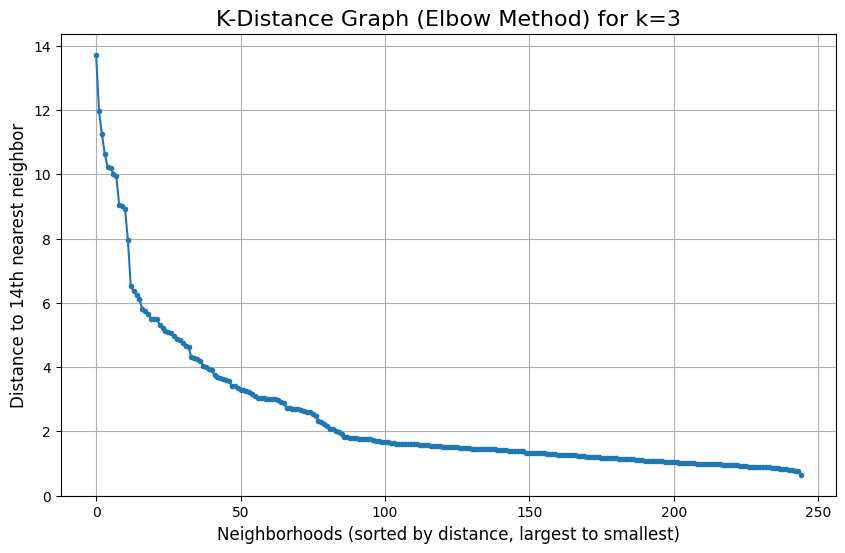

In [ ]:
# k is 63 based on the min_samples we chose
k = 3
X_features = norm_df.drop("Street_Name", axis=1).values

# Fit the algorithm on our 13 PCA data
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_features)

# Calculate distances
distances, indices = neighbors_fit.kneighbors(X_features)

# Extract the distance to the 3th neighbor ( most distant neighbor of the 3 )
k_distances = distances[:, k-1]

# FLIP THE GRAPH: Sort the distances in descending order using [::-1]
k_distances_sorted_desc = np.sort(k_distances)[::-1]

# lot the flipped K-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances_sorted_desc, marker='.', linestyle='solid')
plt.title(f'K-Distance Graph (Elbow Method) for k={k}', fontsize=16)
plt.xlabel('Neighborhoods (sorted by distance, largest to smallest)', fontsize=12)
plt.ylabel('Distance to 14th nearest neighbor', fontsize=12)
plt.grid(True)
plt.show()

We can see that between the elbow is between 1.75~ to 2. 

Let's run a for loop on this range of eps values to see which one gets us the better resoults.

In [ ]:
# Let's test eps values from 1 up to 4 in increments of 0.25
for eps_value in np.arange(1, 100, 0.25):
    
    # Run DBSCAN with the current eps and our locked-in min_samples of 14
    db = DBSCAN(eps=eps_value, min_samples = 2).fit(norm_df.drop("Street_Name", axis=1))
    labels = db.labels_
    
    # Calculate clusters and noise
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)

    # Only print results if it found more than 1 cluster
    if n_clusters_ > 1:
        print(f"eps={eps_value:.2f} | Clusters: {n_clusters_} | Noise Points: {n_noise_} -> {(n_noise_/245)*100:.2f} %") # 245 is the amount of samples

eps=1.00 | Clusters: 17 | Noise Points: 176 -> 71.84 %
eps=1.25 | Clusters: 11 | Noise Points: 141 -> 57.55 %
eps=1.50 | Clusters: 8 | Noise Points: 97 -> 39.59 %
eps=1.75 | Clusters: 3 | Noise Points: 80 -> 32.65 %
eps=2.00 | Clusters: 2 | Noise Points: 78 -> 31.84 %
eps=2.25 | Clusters: 2 | Noise Points: 75 -> 30.61 %
eps=2.50 | Clusters: 4 | Noise Points: 69 -> 28.16 %
eps=2.75 | Clusters: 4 | Noise Points: 56 -> 22.86 %
eps=3.00 | Clusters: 4 | Noise Points: 52 -> 21.22 %
eps=3.25 | Clusters: 4 | Noise Points: 46 -> 18.78 %
eps=3.50 | Clusters: 5 | Noise Points: 36 -> 14.69 %
eps=3.75 | Clusters: 5 | Noise Points: 28 -> 11.43 %
eps=4.00 | Clusters: 5 | Noise Points: 28 -> 11.43 %
eps=4.25 | Clusters: 4 | Noise Points: 26 -> 10.61 %
eps=4.50 | Clusters: 4 | Noise Points: 24 -> 9.80 %
eps=4.75 | Clusters: 4 | Noise Points: 18 -> 7.35 %
eps=5.00 | Clusters: 4 | Noise Points: 18 -> 7.35 %
eps=5.25 | Clusters: 3 | Noise Points: 17 -> 6.94 %
eps=5.50 | Clusters: 3 | Noise Points: 15 -> 6

We can see that the first optimal eps values for which we get a low amount of noise is for eps=3.5 with 4 clusters.

Let's choose those hyperparameters.

In [ ]:
# Running DBSCAN on the parameters we found
db_final = DBSCAN(eps=4.25, min_samples = 2).fit(norm_df.drop("Street_Name",axis = 1))
labels = db_final.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

# Attaching the cluster lablels to the data pre pca and normalization
pre_norm_df_final["Cluster"] = db_final.labels_

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 4
Estimated number of noise points: 26


# Showing the clusters on the map

In [19]:
output(labels)

The labels: 0     -1
1     -1
2      0
3      0
4      0
      ..
240    3
241   -1
242   -1
243    3
244   -1
Length: 245, dtype: int64
Value Counts:
  0    212
-1     26
 1      3
 2      2
 3      2
Name: count, dtype: int64


-1 represents noise and 0 , 1 , 2 , 3 are the clusters.

problem is , most of the values are in the same cluster... not helpful at all. solutions from easiest to hardest:

* not use pca. only normalization.

* try to find better hyperparams

* maybe there are more solutions but i didnt think of any yet

🚨 ALERT: Found 3 small clusters! Highlighting them in neon.
Small Cluster IDs: [1, 2, 3]


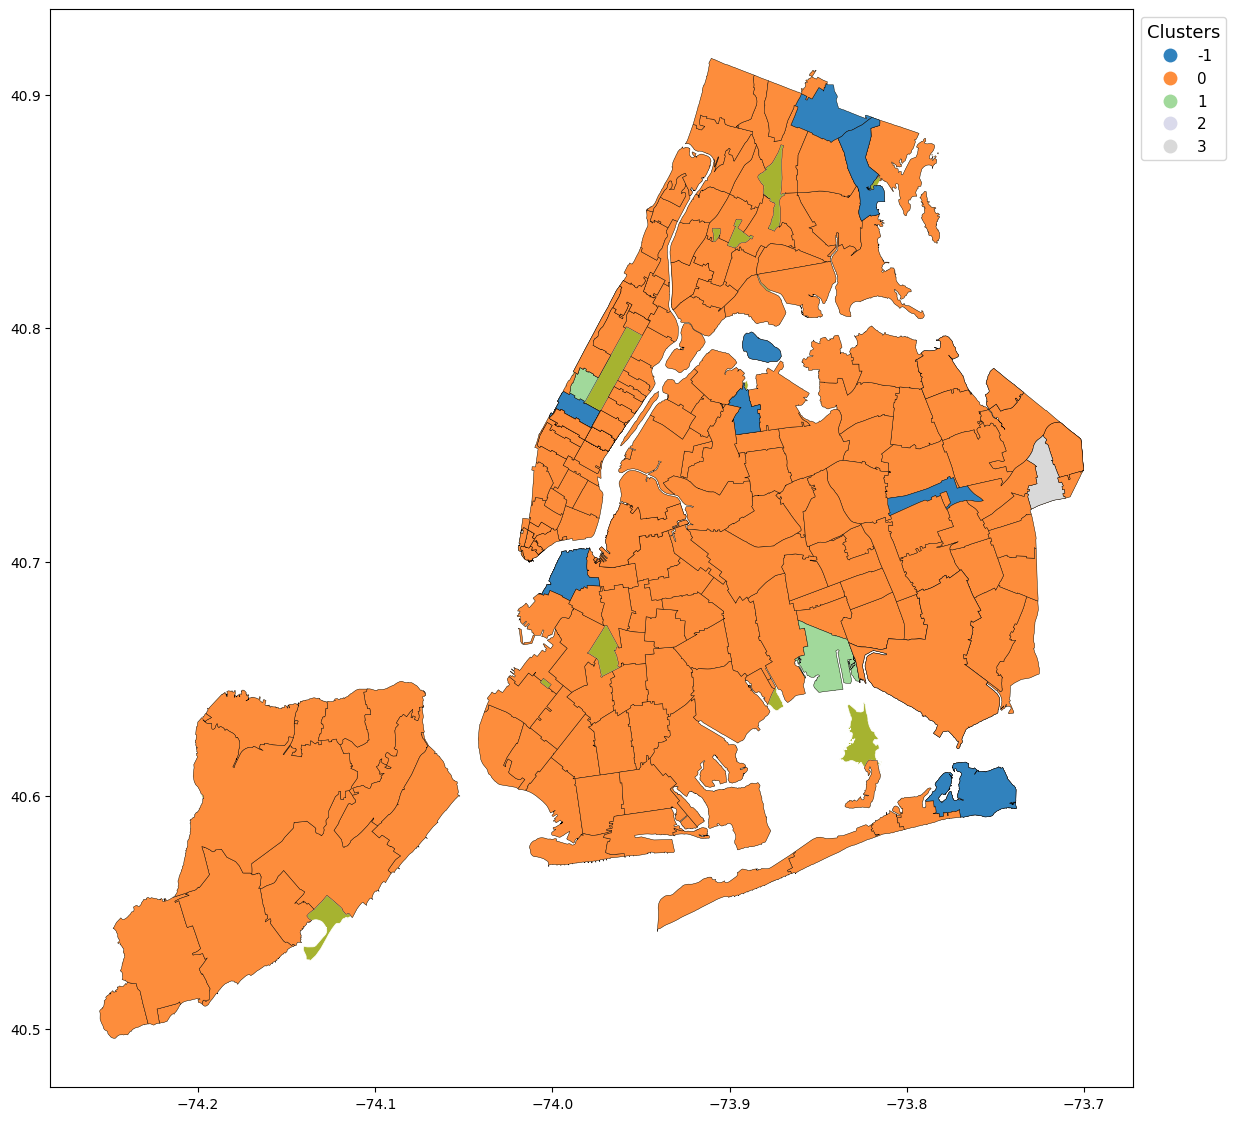

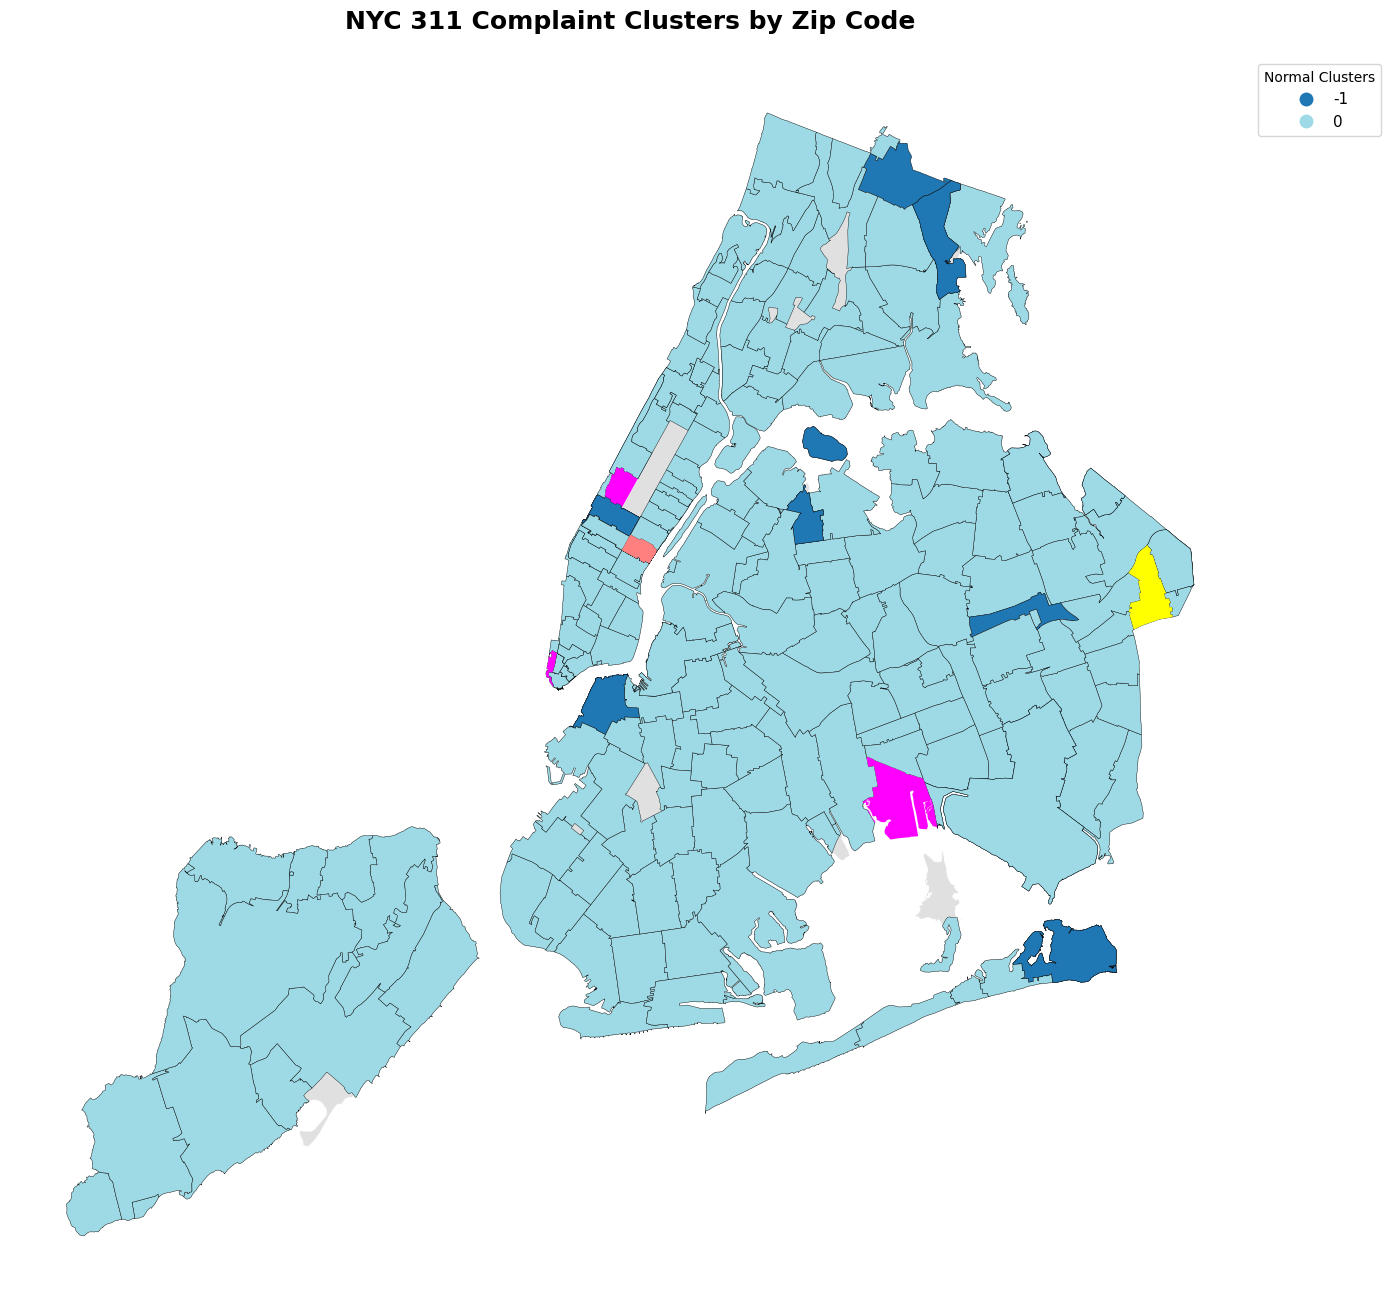

In [ ]:
# 2. Prepare your dataframe for the merge
pree_norm_df_final = pre_norm_df_final.reset_index()

# Clean up zip codes to remove decimals and ensure standard format
pree_norm_df_final['Street_Name'] = (
    pree_norm_df_final['Street_Name']
    .astype(str)
    .str.split('.')
    .str[0]
    .str.zfill(5)
)
nyc_map['modzcta'] = nyc_map['modzcta'].astype(str).str.strip()

# 3. The Ultimate NYC Zip Crosswalk
# This maps point/vanity zips, airports, splits, and former "trash" zips to their parent polygons
zip_crosswalk = {
    # Midtown Manhattan Vanity Zips
    '10118': '10001', '10119': '10001', '10120': '10001', '10121': '10001', 
    '10122': '10001', '10123': '10001', '10151': '10022', '10152': '10022', 
    '10153': '10022', '10154': '10022', '10155': '10022', '10165': '10017', 
    '10166': '10017', '10167': '10017', '10168': '10017', '10169': '10017', 
    '10170': '10017', '10171': '10017', '10172': '10017', '10173': '10017', 
    '10174': '10017', '10020': '10036', '10041': '10004', '10045': '10005', 
    '10048': '10007', '10055': '10022', '10080': '10007', '10103': '10019', 
    '10105': '10019', '10106': '10019', '10107': '10019', '10110': '10036', 
    '10111': '10036', '10112': '10036', '10115': '10027', '10158': '10017', 
    '10162': '10021', '10175': '10017', '10176': '10017', '10177': '10017', 
    '10178': '10017', '10179': '10017',
    
    # Financial District / Downtown
    '10271': '10005', '10278': '10007', '10279': '10007', '10281': '10280',
    
    # Brooklyn Zips & Splits
    '11249': '11211', '11241': '11201', '11242': '11201', '11251': '11201',
    
    # Queens / Airports / Special Facilities
    '11359': '11360', # Fort Totten
    '11371': '11370', # LaGuardia Airport
    '11430': '11434', # JFK Airport
    '11695': '11691', # Far Rockaway
    '11005': '11004', # Glen Oaks border

    # --- FORMER TRASH ZIPS INCORPORATED HERE ---
    
    # Bordering Nassau & Westchester Counties (Mapped to closest NYC neighborhood)
    '10803': '10475', # Pelham Manor -> mapped to Bronx border
    '11001': '11004', # Floral Park (Nassau) -> mapped to Floral Park (Queens)
    '11021': '11363', # Great Neck -> mapped to Little Neck
    '11040': '11004', # New Hyde Park -> mapped to Floral Park (Queens)
    '11096': '11691', # Inwood (Nassau) -> mapped to Far Rockaway
    '11803': '11426', # Plainview -> mapped to Bellerose (Eastern Queens edge)

    # NYC Vanity, Parks, and Error Defaults
    '00083': '10024', # Central Park -> mapped to Upper West Side
    '10000': '10001', # Generic NYC Error -> mapped to Midtown
    '10400': '10451', # Generic Bronx Error -> mapped to South Bronx

}

# Apply crosswalk maps
pree_norm_df_final['Street_Name'] = pree_norm_df_final['Street_Name'].replace(zip_crosswalk)

# Notice: The junk filtering code block was completely removed so these rows survive.

# 4. Merge the geographic polygons with your clustering labels
mapped_clusters = nyc_map.merge(
    pree_norm_df_final, 
    left_on='modzcta', 
    right_on='Street_Name', 
    how='inner'
)

# 5. Plot the Choropleth Map
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# Plot a light grey base map of ALL NYC zip codes behind your data for context
nyc_map.plot(ax=ax, color="#a6b330", edgecolor='white', linewidth=0.5)

# Plot your specific clusters
mapped_clusters.plot(
    column='Cluster', 
    ax=ax, 
    categorical=True, 
    legend=True,
    cmap='tab20c',      # Switched to tab20 to easily handle up to 20 distinct categories
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'loc': 'upper left', 
        'bbox_to_anchor': (1, 1), 
        'title': "Clusters", 
        'fontsize': 11,
        'title_fontsize': 13
    }
)


# 1. Define what makes a cluster "small" (e.g., 3 or fewer ZIP codes)
small_cluster_threshold = 3

# Count how many ZIP codes are in each cluster
cluster_sizes = mapped_clusters['Cluster'].value_counts()

# Identify which cluster IDs are considered "small"
small_cluster_ids = cluster_sizes[cluster_sizes <= small_cluster_threshold].index.tolist()

# 2. Split your dataframe into "Normal" and "Small" clusters
normal_clusters_df = mapped_clusters[~mapped_clusters['Cluster'].isin(small_cluster_ids)]
small_clusters_df = mapped_clusters[mapped_clusters['Cluster'].isin(small_cluster_ids)]

# 3. Start Plotting
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# Plot the base NYC map first (the background)
nyc_map.plot(ax=ax, color="#e0e0e0", edgecolor='white', linewidth=0.5)

# Plot the NORMAL clusters (using your standard tab20 colormap and normal borders)
normal_clusters_df.plot(
    column='Cluster', 
    ax=ax, 
    categorical=True, 
    legend=True,
    cmap='tab20',
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'loc': 'upper left', 
        'bbox_to_anchor': (1, 1), 
        'title': "Normal Clusters", 
        'fontsize': 11
    }
)

# 4. THE MAGIC TRICK: Plot the SMALL clusters ON TOP with neon colors and NO borders
if not small_clusters_df.empty:
    small_clusters_df.plot(
        column='Cluster', 
        ax=ax, 
        categorical=True, 
        cmap='spring',     # 'spring' gives very bright magenta/yellow/neon colors
        edgecolor='none',  # No borders so the color doesn't get swallowed
        zorder=5           # Forces these polygons to be drawn on top of everything else
    )
    
    # Optional: Print a little alert so you know the code found them
    print(f"🚨 ALERT: Found {len(small_cluster_ids)} small clusters! Highlighting them in neon.")
    print(f"Small Cluster IDs: {small_cluster_ids}")


plt.title('NYC 311 Complaint Clusters by Street', fontsize=18, fontweight='bold', pad=20)
plt.axis('off') 
plt.tight_layout()
plt.show()